In [13]:
# CELL 1: IMPORTS AND DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("muted")

print("Loading dataset...")
df = pd.read_csv('final_mlops_dataset.csv')

# Ensure Date is a datetime object
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# THE UPGRADE: Sort ONLY by Date to ensure a proper chronological split across all states
df = df.sort_values(by='Date').reset_index(drop=True)

print(f"Dataset Loaded Successfully! Shape: {df.shape}")
display(df.head())

Loading dataset...
Dataset Loaded Successfully! Shape: (38150, 43)


,Date,State,Region,Energy_Consumption_MU,MaxDemand_MW,PeakShortage_MW,Reg_EveningDemand_MW,Reg_EveningShortage_MW,Reg_EnergyMet_MU,Reg_HydroGen_MU,...,Roll7_AvgHeatStress,Roll7_AvgCDD,Roll7_AvgCloudCover,Roll7_AvgApparentTemp,Roll7_TotalPrecip,Roll7_TotalEvapo,Days_Above_38C_Week,Is_Holiday,Day_Of_Week,Is_Weekend
0,2023-04-17,Bihar,ER,127.2,6143.0,209.0,27455.0,479.0,605.0,45.0,...,49.247211,14.177143,26.885714,37.480000,0.0,61.4280,6,0,0,0
1,2023-04-17,UP,NR,425.5,22211.0,235.0,59936.0,879.0,1263.0,159.0,...,26.842650,0.694286,22.585714,22.088571,0.0,32.6010,0,0,0,0
2,2023-04-17,Uttarakhand,NR,42.4,2228.0,0.0,59936.0,879.0,1263.0,159.0,...,45.403714,5.742857,23.857143,31.742857,0.0,39.0800,0,0,0,0
3,2023-04-17,Andhra Pradesh,SR,244.4,12093.0,0.0,51325.0,NaN,1287.0,89.0,...,59.381096,13.796429,25.450000,41.784286,0.0,48.5465,7,0,0,0
4,2023-04-17,Karnataka,SR,301.3,15790.0,0.0,51325.0,NaN,1287.0,89.0,...,20.312429,0.000000,13.857143,16.557143,0.0,26.2400,0,0,0,0


Calculating Correlation Matrix...


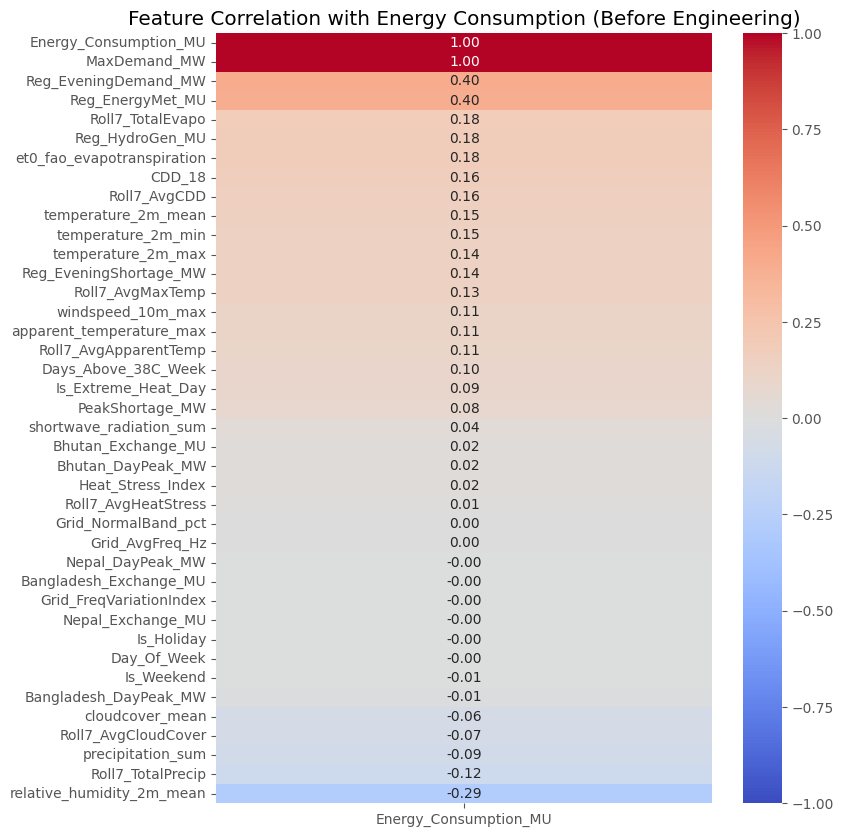

In [14]:
# CELL 2: INITIAL CORRELATION MATRIX
numeric_df = df.select_dtypes(include=[np.number])

print("Calculating Correlation Matrix...")
corr_matrix = numeric_df.corr()

target_corr = corr_matrix[['Energy_Consumption_MU']].sort_values(by='Energy_Consumption_MU', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Feature Correlation with Energy Consumption (Before Engineering)")
plt.show()

In [15]:
# CELL 3: FEATURE ENGINEERING
print("Engineering Cyclical Time Features...")

df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

# Cyclical encoding for Month and Day of Year
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12.0)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)
df['DayOfYear_Sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
df['DayOfYear_Cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)

df = df.drop(columns=['Month', 'DayOfYear'])

print("Feature Engineering Complete. Current Dataset Shape:", df.shape)

Engineering Cyclical Time Features...
Feature Engineering Complete. Current Dataset Shape: (38150, 47)


In [16]:
# CELL 4: DATA PREPARATION & ONE-HOT ENCODING
target = 'Energy_Consumption_MU'

# THE UPGRADE: One-Hot Encode the 'State' column so XGBoost understands geography
print("Applying One-Hot Encoding to States...")
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=False)

exclude_cols = ['Date', 'Region', target, 'Reg_EveningShortage_MW',
                'PeakShortage_MW', 'MaxDemand_MW', 'Reg_EveningDemand_MW', 'Reg_EnergyMet_MU']

# 1. ADVANCED FEATURES (Lags, Calendar, Weather, Holidays, and States)
features_all = [col for col in df_encoded.columns if col not in exclude_cols]
features_all = [col for col in features_all if df_encoded[col].dtype != 'object']

# 2. PURE BENCHMARK FEATURES (Excluding weather AND Holidays)
exogenous_keywords = ['Temp', 'Heat', 'Humidity', 'Precip', 'Solar', 'Cloud', 'Evapo', 'temperature', 'windspeed', '38C', 'Holiday']
features_benchmark = [col for col in features_all if not any(keyword in col for keyword in exogenous_keywords)]

print(f"Advanced Model feature count: {len(features_all)}")
print(f"Benchmark Model feature count: {len(features_benchmark)}")

# Proper Time-series split (Train 80% past, Test 20% future)
train_size = int(len(df_encoded) * 0.8)
train_df = df_encoded.iloc[:train_size].copy()
test_df = df_encoded.iloc[train_size:].copy()

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

y_train = train_df[target]
y_test = test_df[target]

Applying One-Hot Encoding to States...
Advanced Model feature count: 77
Benchmark Model feature count: 62



Training Benchmark Model (Lag & Calendar Only)...
--- Benchmark Model (Lag & Calendar Only) Results ---
R-Squared (Higher is better): 0.9864
MAPE (Lower is better):       47.08%
MAE:                          10.72 MU
RMSE:                         16.72 MU

Training Advanced Model (Weather + Holidays + States)...
--- Advanced Model (Weather + Holidays + States) Results ---
R-Squared (Higher is better): 0.9883
MAPE (Lower is better):       50.07%
MAE:                          10.54 MU
RMSE:                         15.50 MU

Generating Feature Importance Plot...


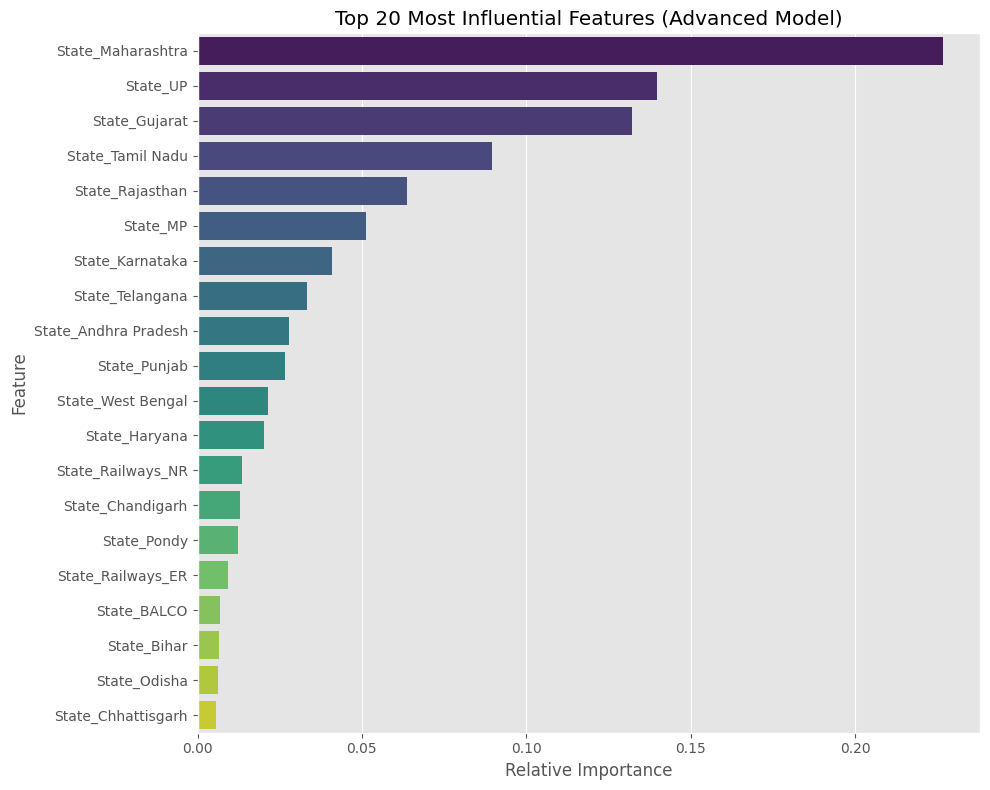

In [17]:
# CELL 5: MODEL TRAINING AND COMPARISON

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # THE UPGRADE: Mask out rows where actual consumption is near zero to prevent infinite MAPE
    mask = y_true > 1
    if np.sum(mask) == 0:
        return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def train_and_evaluate(features, model_name):
    print(f"\nTraining {model_name}...")
    X_train = train_df[features]
    X_test = test_df[features]

    model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mape = mean_absolute_percentage_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"--- {model_name} Results ---")
    print(f"R-Squared (Higher is better): {r2:.4f}")
    print(f"MAPE (Lower is better):       {mape:.2f}%")
    print(f"MAE:                          {mae:.2f} MU")
    print(f"RMSE:                         {rmse:.2f} MU")

    return model

# Train both models
model_bench = train_and_evaluate(features_benchmark, "Benchmark Model (Lag & Calendar Only)")
model_advanced = train_and_evaluate(features_all, "Advanced Model (Weather + Holidays + States)")

# THE UPGRADE: Plot Feature Importances for the Advanced Model
print("\nGenerating Feature Importance Plot...")
plt.figure(figsize=(10, 8))
importances = pd.Series(model_advanced.feature_importances_, index=features_all).sort_values(ascending=False).head(20)
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Top 20 Most Influential Features (Advanced Model)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
# CELL 6: HYPERPARAMETER TUNING FOR THE ADVANCED MODEL
from sklearn.model_selection import RandomizedSearchCV

print("Setting up Randomized Search for Hyperparameter Tuning...")

# 1. Define the parameter grid we want to explore
param_grid = {
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [300, 500, 700],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 1, 5]
}

# 2. Initialize a base XGBoost Regressor
base_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# 3. Set up the RandomizedSearchCV
# n_iter=20 means it will test 20 random combinations from our grid above
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error', # We want to minimize RMSE!
    cv=3, # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Define our X and y for the Advanced Model
X_train_adv = train_df[features_all]
y_train_adv = train_df[target]

print("Starting the search... (This might take a few minutes depending on your Colab runtime)")
random_search.fit(X_train_adv, y_train_adv)

# 5. Output the results
print("\n🎉 Tuning Complete!")
print("The absolute best parameters found are:")
best_params = random_search.best_params_
for key, value in best_params.items():
    print(f"  {key}: {value}")

# You can now use random_search.best_estimator_ as your final, tuned model!

Setting up Randomized Search for Hyperparameter Tuning...
Starting the search... (This might take a few minutes depending on your Colab runtime)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🎉 Tuning Complete!
The absolute best parameters found are:
  subsample: 1.0
  n_estimators: 700
  max_depth: 4
  learning_rate: 0.1
  gamma: 1
  colsample_bytree: 0.9


In [19]:
# CELL 7: FINAL TUNED XGBOOST MODEL
print("Training the Final Tuned Advanced XGBoost Model...")

# 1. Initialize the model with our newly discovered optimal parameters
final_xgb_model = xgb.XGBRegressor(
    subsample=1.0,
    n_estimators=700,
    max_depth=4,
    learning_rate=0.1,
    gamma=1,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

# 2. Define the training and testing data for the advanced features
X_train_final = train_df[features_all]
y_train_final = train_df[target]
X_test_final = test_df[features_all]
y_test_final = test_df[target]

# 3. Train the final model
final_xgb_model.fit(X_train_final, y_train_final)

# 4. Make predictions
final_predictions = final_xgb_model.predict(X_test_final)

# 5. Calculate and display the final evaluation metrics
final_mae = mean_absolute_error(y_test_final, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test_final, final_predictions))
final_mape = mean_absolute_percentage_error(y_test_final, final_predictions)
final_r2 = r2_score(y_test_final, final_predictions)

print("\n--- Final Tuned XGBoost Results ---")
print(f"R-Squared (Higher is better): {final_r2:.4f}")
print(f"MAPE (Lower is better):       {final_mape:.2f}%")
print(f"MAE:                          {final_mae:.2f} MU")
print(f"RMSE:                         {final_rmse:.2f} MU")

Training the Final Tuned Advanced XGBoost Model...

--- Final Tuned XGBoost Results ---
R-Squared (Higher is better): 0.9906
MAPE (Lower is better):       26.79%
MAE:                          8.30 MU
RMSE:                         13.87 MU


Step 1: Scaling the data to 0-1 for the Neural Network...
Step 2: Creating 3D Time-Series Sequences & Splitting Safely...
LSTM Training Shape: (30080, 14, 77)
LSTM Testing Shape:  (7524, 14, 77)
Step 3: Building the LSTM Neural Network Architecture...
Step 4: Training the LSTM Model (With Early Stopping)...
Epoch 1/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0080 - val_loss: 0.0015
Epoch 2/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 3/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 4/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 9.8504e-04 - val_loss: 9.9264e-04
Epoch 5/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 8.5471e-04 - val_loss: 0.0012
Epoch 6/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 7.2842e-04 - val_loss: 9.6404e-04
Epoch 7/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 7.2399e-04 - val_loss: 8.2847e-04
Epoch 8/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/ste

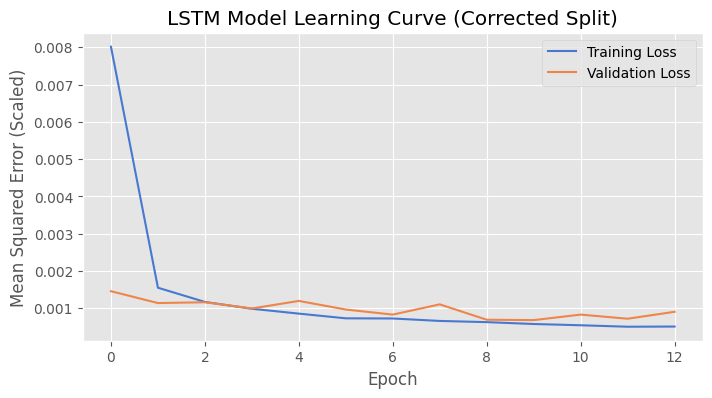

In [21]:
# CELL 8: DEEP LEARNING - LSTM DATA PREPARATION & MODELING (CORRECTED)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("Step 1: Scaling the data to 0-1 for the Neural Network...")

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

target = 'Energy_Consumption_MU'
scaled_features = feature_scaler.fit_transform(df_encoded[features_all])
scaled_target = target_scaler.fit_transform(df_encoded[[target]])

df_scaled = pd.DataFrame(scaled_features, columns=features_all)
df_scaled[target] = scaled_target
df_scaled['State'] = df['State'].values

print("Step 2: Creating 3D Time-Series Sequences & Splitting Safely...")

WINDOW_SIZE = 14
X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm = [], [], [], []

states = df_scaled['State'].unique()

# THE FIX: We split the data 80/20 INSIDE this loop so every state is represented fairly!
for state in states:
    state_data = df_scaled[df_scaled['State'] == state].reset_index(drop=True)
    state_X = state_data[features_all].values
    state_y = state_data[target].values

    state_X_seq, state_y_seq = [], []

    # Slide the 14-day window down this specific state's timeline
    for i in range(len(state_data) - WINDOW_SIZE):
        state_X_seq.append(state_X[i:(i + WINDOW_SIZE)])
        state_y_seq.append(state_y[i + WINDOW_SIZE])

    # Split THIS state's sequences chronologically (80% Train, 20% Test)
    split_idx = int(len(state_X_seq) * 0.8)

    X_train_lstm.extend(state_X_seq[:split_idx])
    y_train_lstm.extend(state_y_seq[:split_idx])

    X_test_lstm.extend(state_X_seq[split_idx:])
    y_test_lstm.extend(state_y_seq[split_idx:])

# Convert everything to numpy arrays for TensorFlow
X_train_lstm, y_train_lstm = np.array(X_train_lstm), np.array(y_train_lstm)
X_test_lstm, y_test_lstm = np.array(X_test_lstm), np.array(y_test_lstm)

print(f"LSTM Training Shape: {X_train_lstm.shape}")
print(f"LSTM Testing Shape:  {X_test_lstm.shape}")

print("Step 3: Building the LSTM Neural Network Architecture...")

model_lstm = Sequential()
model_lstm.add(LSTM(units=64, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=32, activation='relu'))
model_lstm.add(Dense(units=1))

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

print("Step 4: Training the LSTM Model (With Early Stopping)...")

# THE UPGRADE: Early Stopping will monitor 'val_loss' and stop training if it doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stop], # Apply the early stopping rule
    verbose=1
)

print("\nStep 5: Evaluating and Comparing against XGBoost...")

lstm_scaled_preds = model_lstm.predict(X_test_lstm)

# INVERSE TRANSFORM: Convert back to MegaWatts
y_test_real = target_scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
lstm_real_preds = target_scaler.inverse_transform(lstm_scaled_preds)

lstm_mae = mean_absolute_error(y_test_real, lstm_real_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_real_preds))
lstm_r2 = r2_score(y_test_real, lstm_real_preds)

mask = y_test_real > 1
lstm_mape = np.mean(np.abs((y_test_real[mask] - lstm_real_preds[mask]) / y_test_real[mask])) * 100

print(f"\n--- Final LSTM Network Results ---")
print(f"R-Squared: {lstm_r2:.4f}")
print(f"MAPE:      {lstm_mape:.2f}%")
print(f"MAE:       {lstm_mae:.2f} MU")
print(f"RMSE:      {lstm_rmse:.2f} MU")

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Learning Curve (Corrected Split)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Scaled)')
plt.legend()
plt.show()

Step 1: Initializing the SHAP Explainer...
Step 2: Calculating SHAP values for the testing dataset...

--- GLOBAL EXPLANATION (Summary Plot) ---
This chart shows how features impact the model overall.
Red dots = High feature value (e.g., High Temp, or Is_Holiday = 1)
Blue dots = Low feature value (e.g., Low Temp, or Is_Holiday = 0)
Dots pushed to the right INCREASE energy demand. Dots pushed to the left DECREASE it.


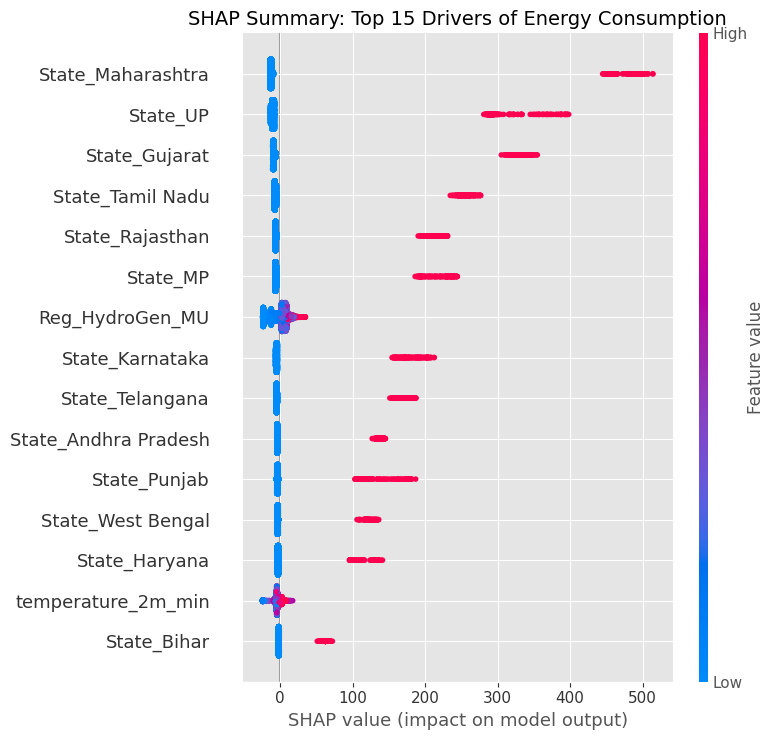


--- LOCAL EXPLANATION (Waterfall Plot) ---
This chart breaks down the exact math for a SINGLE DAY's prediction.


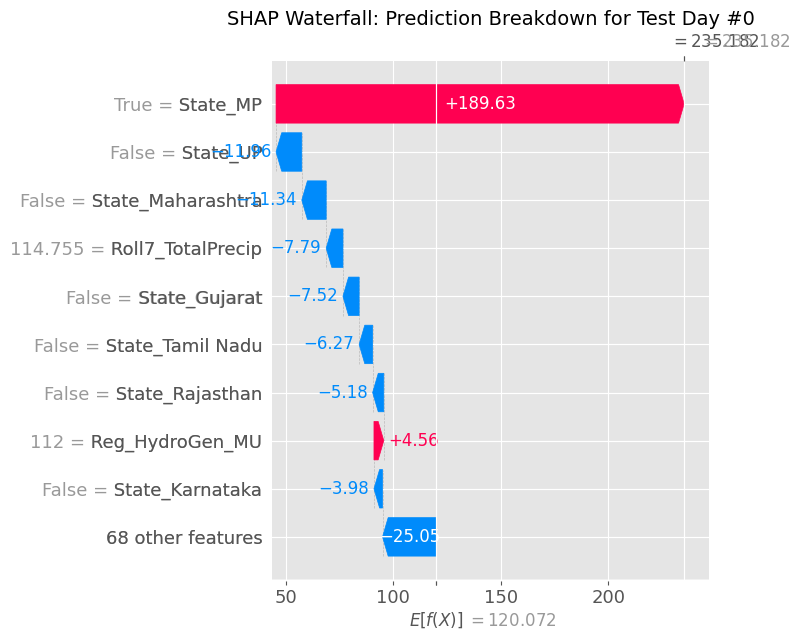

In [22]:
# CELL 9: EXPLAINABLE AI WITH SHAP
# Install the SHAP library (Colab usually doesn't have it by default)
!pip install shap -q

import shap
import matplotlib.pyplot as plt
import numpy as np

print("Step 1: Initializing the SHAP Explainer...")
# Create a SHAP explainer specifically designed for tree-based models like XGBoost
explainer = shap.TreeExplainer(final_xgb_model)

print("Step 2: Calculating SHAP values for the testing dataset...")
# This calculates the game-theory "credit" for every feature across every day in the test set
# We use X_test_final so it analyzes data the model has never trained on
shap_values = explainer(X_test_final)

print("\n--- GLOBAL EXPLANATION (Summary Plot) ---")
print("This chart shows how features impact the model overall.")
print("Red dots = High feature value (e.g., High Temp, or Is_Holiday = 1)")
print("Blue dots = Low feature value (e.g., Low Temp, or Is_Holiday = 0)")
print("Dots pushed to the right INCREASE energy demand. Dots pushed to the left DECREASE it.")

# Step 3: Generate the Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_final, max_display=15, show=False)
plt.title("SHAP Summary: Top 15 Drivers of Energy Consumption", fontsize=14)
plt.tight_layout()
plt.show()


print("\n--- LOCAL EXPLANATION (Waterfall Plot) ---")
print("This chart breaks down the exact math for a SINGLE DAY's prediction.")

# Step 4: Generate the Waterfall Plot for a single prediction
# We will pick the very first day in our test set (index 0) as an example
day_index = 0

plt.figure(figsize=(10, 6))
# The waterfall plot shows how we get from the expected baseline (E[f(X)]) to the final prediction (f(x))
shap.plots.waterfall(shap_values[day_index], max_display=10, show=False)
plt.title(f"SHAP Waterfall: Prediction Breakdown for Test Day #{day_index}", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# CELL 1: ROBUST TARGET NORMALIZATION (DATA PREPARATION)
import pandas as pd
import numpy as np

print("Step 1: Calculating State Baselines (7-Day Rolling Average)...")
df['Baseline_Energy'] = df.groupby('State')['Energy_Consumption_MU'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

print("Step 2: Calculating Logarithmic Change (Our Robust Target)...")
# THE UPGRADE: We use np.log1p (which means log(x + 1)) to safely handle any absolute zeros.
# This calculates the difference in magnitude without ever dividing!
df['Log_Change'] = np.log1p(df['Energy_Consumption_MU']) - np.log1p(df['Baseline_Energy'])

# Drop rows that don't have enough history to form a baseline
df_target_norm = df.dropna(subset=['Baseline_Energy', 'Log_Change']).reset_index(drop=True)

print("Step 3: Re-Applying One-Hot Encoding...")
df_norm_encoded = pd.get_dummies(df_target_norm, columns=['State'], drop_first=False)

print(f"Data is prepped and mathematically safe! New Shape: {df_norm_encoded.shape}")
display(df_norm_encoded[['Date', 'Energy_Consumption_MU', 'Baseline_Energy', 'Log_Change']].head())

Step 1: Calculating State Baselines (7-Day Rolling Average)...
Step 2: Calculating Logarithmic Change (Our Robust Target)...
Step 3: Re-Applying One-Hot Encoding...
Data is prepped and mathematically safe! New Shape: (38099, 88)


,Date,Energy_Consumption_MU,Baseline_Energy,Log_Change
0,2023-04-18,3.8,3.8,0.000000
1,2023-04-18,277.0,281.3,-0.015349
2,2023-04-18,439.7,425.5,0.032752
3,2023-04-18,43.9,42.4,0.033978
4,2023-04-18,246.4,244.4,0.008117


Training Generalized XGBoost Model...

--- Final Generalized Model Results ---
R-Squared: 0.9945
MAPE: 4.81%
MAE:  4.65 MU
RMSE: 10.66 MU

Generating Generalized Feature Importance...


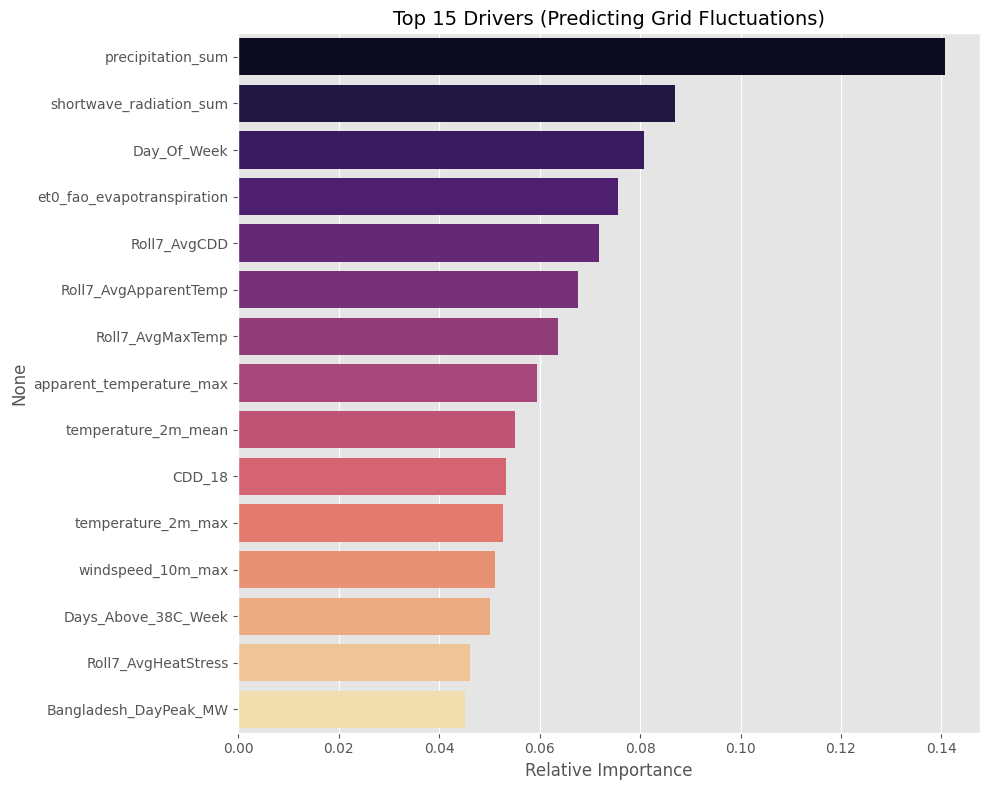

In [28]:
# CELL 2: GENERALIZED MODEL TRAINING & EVALUATION (LEAK FIXED)
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define our new robust target
target_norm = 'Log_Change'

# THE FIX: Added 'Percentage_Change' to the exclusion list to prevent Data Leakage!
exclude_cols_norm = ['Date', 'Region', 'Energy_Consumption_MU', 'Reg_EnergyMet_MU',
                     'Baseline_Energy', target_norm, 'Percentage_Change', 'Reg_EveningShortage_MW',
                     'PeakShortage_MW', 'MaxDemand_MW', 'Reg_EveningDemand_MW']

features_norm = [col for col in df_norm_encoded.columns if col not in exclude_cols_norm]
features_norm = [col for col in features_norm if df_norm_encoded[col].dtype != 'object']

# 2. Chronological Time-Series Split
train_size_norm = int(len(df_norm_encoded) * 0.8)
train_df_norm = df_norm_encoded.iloc[:train_size_norm].copy().fillna(0)
test_df_norm = df_norm_encoded.iloc[train_size_norm:].copy().fillna(0)

X_train_norm = train_df_norm[features_norm]
y_train_norm = train_df_norm[target_norm] # Training on Logarithmic Change!
X_test_norm = test_df_norm[features_norm]

print("Training Generalized XGBoost Model...")
norm_xgb_model = xgb.XGBRegressor(
    subsample=1.0, n_estimators=700, max_depth=4,
    learning_rate=0.1, gamma=1, colsample_bytree=0.9,
    random_state=42, n_jobs=-1
)

norm_xgb_model.fit(X_train_norm, y_train_norm)
norm_preds = norm_xgb_model.predict(X_test_norm)

# 3. Inverse Transform the Log Math back to MegaWatts
test_baselines = test_df_norm['Baseline_Energy'].values
real_y_test = test_df_norm['Energy_Consumption_MU'].values

# We reverse the log1p math using expm1 (exponential minus 1)
real_predictions_mu = np.expm1(norm_preds + np.log1p(test_baselines))

# 4. Evaluate the Real MegaWatt Accuracy
norm_r2 = r2_score(real_y_test, real_predictions_mu)

norm_mae = mean_absolute_error(real_y_test, real_predictions_mu)
norm_rmse = np.sqrt(mean_squared_error(real_y_test, real_predictions_mu))

mask = real_y_test > 1
norm_mape = np.mean(np.abs((real_y_test[mask] - real_predictions_mu[mask]) / real_y_test[mask])) * 100

print("\n--- Final Generalized Model Results ---")
print(f"R-Squared: {norm_r2:.4f}")
print(f"MAPE: {norm_mape:.2f}%")
print(f"MAE:  {norm_mae:.2f} MU")
print(f"RMSE: {norm_rmse:.2f} MU")

# 5. Plot the True Feature Importance
print("\nGenerating Generalized Feature Importance...")
plt.figure(figsize=(10, 8))
importances_norm = pd.Series(norm_xgb_model.feature_importances_, index=features_norm).sort_values(ascending=False).head(15)
sns.barplot(x=importances_norm.values, y=importances_norm.index, palette="magma")
plt.title("Top 15 Drivers (Predicting Grid Fluctuations)", fontsize=14)
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [29]:
# CELL 3: HYPERPARAMETER TUNING FOR THE GENERALIZED MODEL
from sklearn.model_selection import RandomizedSearchCV

print("Setting up Randomized Search for Generalized Model Tuning...")

# 1. Define the hyperparameter grid to explore
# We include a slightly wider range for gamma and subsample to give it flexibility
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [300, 500, 700, 1000],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 1, 5]
}

# 2. Initialize the base XGBoost Regressor
base_xgb_norm = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# 3. Set up the Randomized Search
random_search_norm = RandomizedSearchCV(
    estimator=base_xgb_norm,
    param_distributions=param_grid,
    n_iter=20, # Tests 20 random combinations
    scoring='neg_root_mean_squared_error', # Optimizing to minimize RMSE
    cv=3, # 3-fold cross-validation ensures the model is robust
    verbose=2, # Prints progress as it runs
    random_state=42,
    n_jobs=-1
)

print("Starting the search... (This might take a few minutes)")
# 4. Fit the search specifically on our NORMALIZED target data
random_search_norm.fit(X_train_norm, y_train_norm)

# 5. Output the winning parameters
print("\n🎉 Tuning Complete!")
print("The absolute best parameters for the Generalized Model are:")
best_params_norm = random_search_norm.best_params_
for key, value in best_params_norm.items():
    print(f"  {key}: {value}")

Setting up Randomized Search for Generalized Model Tuning...
Starting the search... (This might take a few minutes)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🎉 Tuning Complete!
The absolute best parameters for the Generalized Model are:
  subsample: 0.9
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.05
  gamma: 0
  colsample_bytree: 0.7


Step 1: Training the Final Tuned Generalized XGBoost Model...
Step 2: Predicting and Reversing the Math (Inverse Transform)...
Step 3: Calculating Final Performance Metrics...

--- 🏆 Final Tuned Generalized Model Results ---
R-Squared: 0.9957
MAPE:      4.72%
MAE:       4.24 MU
RMSE:      9.45 MU

Step 4: Generating Final Generalized Feature Importance...


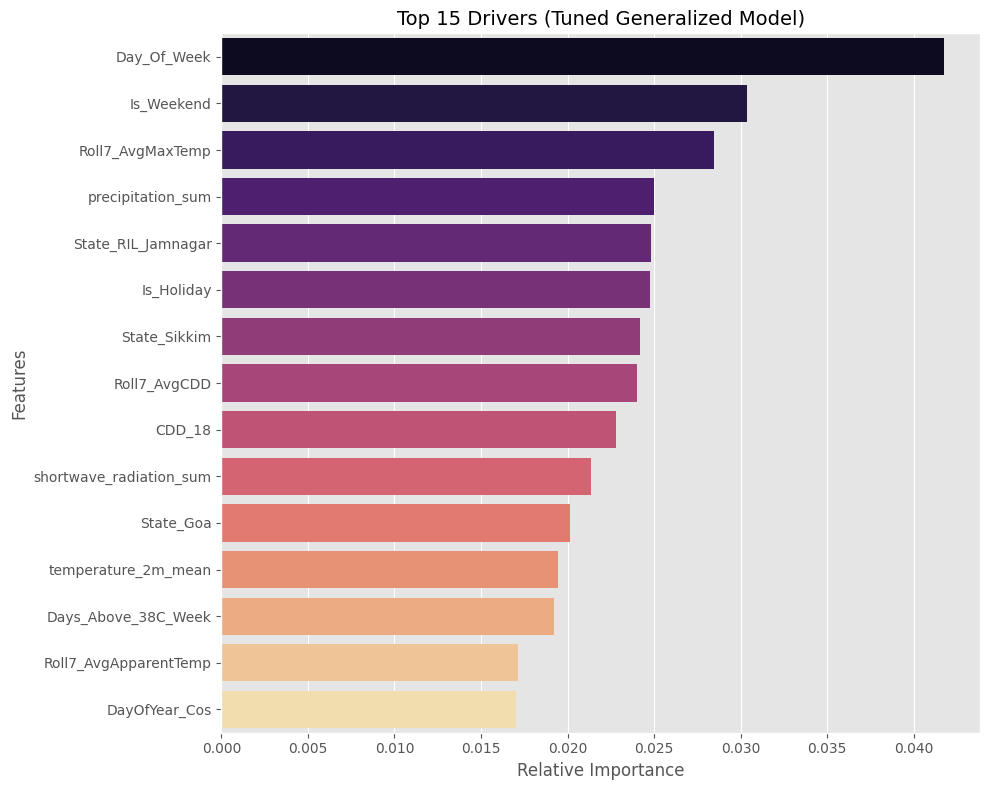

In [30]:
# CELL 4: FINAL TUNED GENERALIZED XGBOOST MODEL
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Step 1: Training the Final Tuned Generalized XGBoost Model...")

# 1. Initialize the model with your absolute best parameters
final_norm_xgb = xgb.XGBRegressor(
    subsample=0.9,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

# 2. Train the model on the logarithmic change target
final_norm_xgb.fit(X_train_norm, y_train_norm)

print("Step 2: Predicting and Reversing the Math (Inverse Transform)...")

# 3. Predict the Logarithmic Change on the test set
norm_preds_tuned = final_norm_xgb.predict(X_test_norm)

# 4. INVERSE TRANSFORM: Convert predictions back to Real MegaWatts (MU)
# The mathematical inverse of log1p(x) is expm1(x).
# We reverse the formula: Final Prediction = exp(Predicted_Log_Change + log(Baseline)) - 1
real_predictions_mu_tuned = np.expm1(norm_preds_tuned + np.log1p(test_baselines))

print("Step 3: Calculating Final Performance Metrics...")

# 5. Evaluate the Real MegaWatt Accuracy against the true test values
final_mae = mean_absolute_error(real_y_test, real_predictions_mu_tuned)
final_rmse = np.sqrt(mean_squared_error(real_y_test, real_predictions_mu_tuned))
final_r2 = r2_score(real_y_test, real_predictions_mu_tuned) # R-Squared added back!

# Safe MAPE Calculation (ignoring near-zero baseline days to prevent infinity errors)
mask = real_y_test > 1
final_mape = np.mean(np.abs((real_y_test[mask] - real_predictions_mu_tuned[mask]) / real_y_test[mask])) * 100

print("\n--- 🏆 Final Tuned Generalized Model Results ---")
print(f"R-Squared: {final_r2:.4f}")
print(f"MAPE:      {final_mape:.2f}%")
print(f"MAE:       {final_mae:.2f} MU")
print(f"RMSE:      {final_rmse:.2f} MU")

print("\nStep 4: Generating Final Generalized Feature Importance...")

# 6. Plot the Final Feature Importance
plt.figure(figsize=(10, 8))
importances_final = pd.Series(final_norm_xgb.feature_importances_, index=features_norm).sort_values(ascending=False).head(15)
sns.barplot(x=importances_final.values, y=importances_final.index, palette="magma")
plt.title("Top 15 Drivers (Tuned Generalized Model)", fontsize=14)
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Step 1: Initializing the SHAP Explainer...
Step 2: Calculating SHAP values for the testing dataset...

--- GLOBAL EXPLANATION (Summary Plot) ---


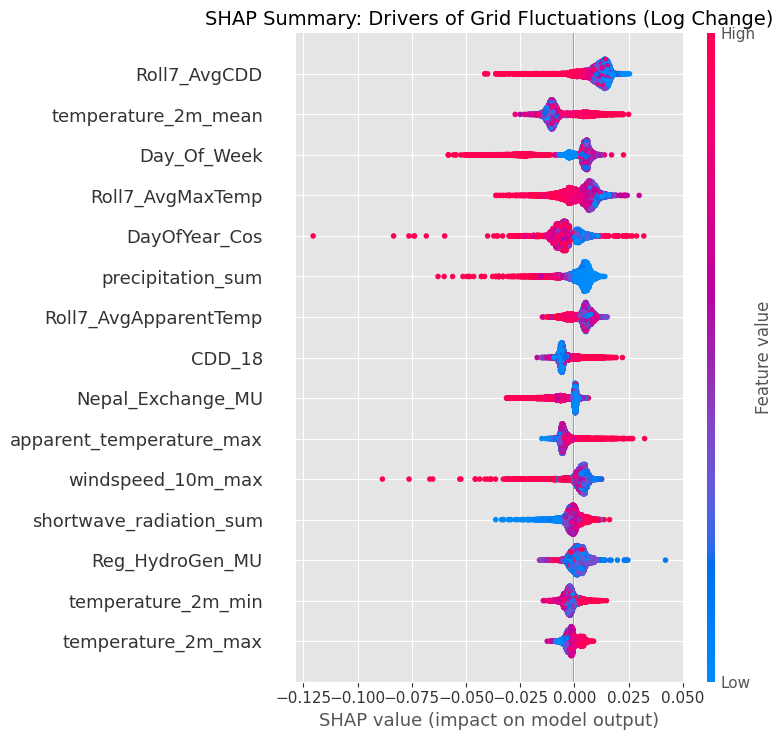


--- LOCAL EXPLANATION (Waterfall Plot) ---
Breaking down the exact math for a SINGLE DAY's fluctuation prediction.


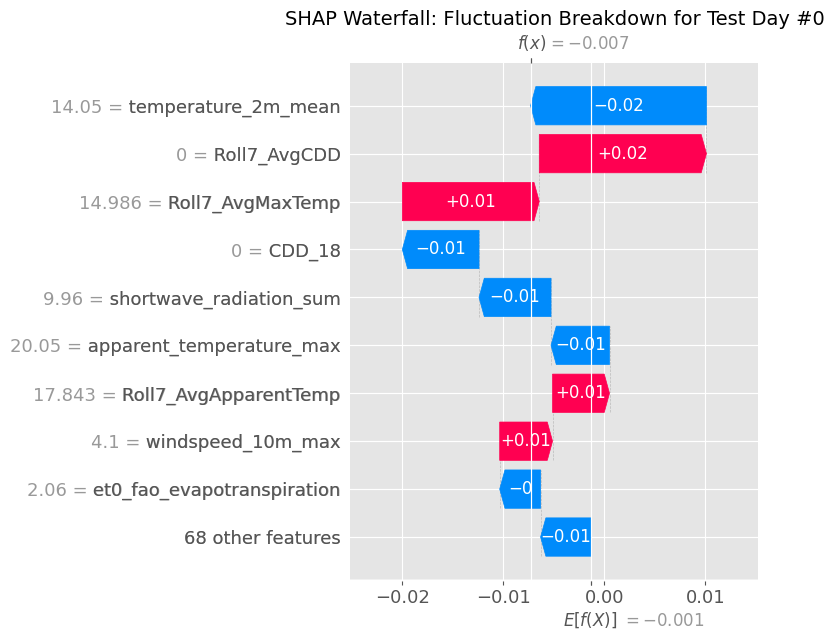

In [31]:
# CELL 5: EXPLAINABLE AI (SHAP) FOR THE GENERALIZED MODEL
!pip install shap -q

import shap
import matplotlib.pyplot as plt

print("Step 1: Initializing the SHAP Explainer...")
# Create a SHAP explainer for our final tuned generalized model
explainer_norm = shap.TreeExplainer(final_norm_xgb)

print("Step 2: Calculating SHAP values for the testing dataset...")
# Calculate the SHAP values using the normalized test features
shap_values_norm = explainer_norm(X_test_norm)

print("\n--- GLOBAL EXPLANATION (Summary Plot) ---")
plt.figure(figsize=(10, 8))
# This plot will show us how high/low values of features impact the Logarithmic Change
shap.summary_plot(shap_values_norm, X_test_norm, max_display=15, show=False)
plt.title("SHAP Summary: Drivers of Grid Fluctuations (Log Change)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n--- LOCAL EXPLANATION (Waterfall Plot) ---")
print("Breaking down the exact math for a SINGLE DAY's fluctuation prediction.")

# Step 3: Generate the Waterfall Plot for the first day in our test set
day_index = 0

plt.figure(figsize=(10, 6))
# This shows how the model adds/subtracts from the baseline fluctuation based on the day's conditions
shap.plots.waterfall(shap_values_norm[day_index], max_display=10, show=False)
plt.title(f"SHAP Waterfall: Fluctuation Breakdown for Test Day #{day_index}", fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
# CELL 6: EXPORTING ARTIFACTS FOR SERVER DEPLOYMENT (CORRECTED)
import joblib

print("Step 1: Exporting the Trained XGBoost Model...")
# We use XGBoost's native save function. It is highly optimized and server-friendly.
model_filename = "generalized_xgboost_model.json"
final_norm_xgb.save_model(model_filename)
print(f" -> Model successfully saved to {model_filename}")

print("\nStep 2: Exporting the Feature Column Structure...")
# We save the exact list of columns the model was trained on.
features_filename = "model_features.pkl"
joblib.dump(features_norm, features_filename)
print(f" -> Feature list successfully saved to {features_filename}")

print("\nStep 3: Exporting the Latest State Baselines...")
# THE FIX: We use 'df_target_norm' instead of 'df_norm_encoded'.
# This dataframe still has the original 'State' column before it was one-hot encoded!
latest_baselines = df_target_norm.groupby('State')['Baseline_Energy'].last().to_dict()
baselines_filename = "state_baselines.pkl"
joblib.dump(latest_baselines, baselines_filename)
print(f" -> State baselines successfully saved to {baselines_filename}")

print("\n🎉 All deployment artifacts have been successfully exported!")

Step 1: Exporting the Trained XGBoost Model...
 -> Model successfully saved to generalized_xgboost_model.json

Step 2: Exporting the Feature Column Structure...
 -> Feature list successfully saved to model_features.pkl

Step 3: Exporting the Latest State Baselines...
 -> State baselines successfully saved to state_baselines.pkl

🎉 All deployment artifacts have been successfully exported!
